# Forecasting with gradient-boosted trees

The same job as notebook 02, with a different model family: XGBoost quantile regression instead of a
Temporal Fusion Transformer.

**Why run it at all.** This one is far cheaper and repeats exactly:

| | TFT | this |
|---|---|---|
| reproducible | needs a GPU | **exactly, on a CPU** |
| one fit | hours | **~1 minute** |
| pinball | 0.1074 | 0.1116 |

⚠️ **These two numbers do not match README §6 / PLAN.md §3** (both currently state TFT 0.1103 /
XGBoost 0.1113, "under 1% apart"). The values above were read directly off the forecast parquets
saved on disk right now (`outputs/forecasts/tft/forecast_validation_recovered.parquet` and the `xgb`
equivalent) via `metrics.quantile_scores`, so they are what the pipeline currently produces - but a
gap of 0.0042 (TFT about 3.9% better) is a different claim from "the two tie," not just a rounding
difference. **Not resolved in this pass** - flagged for a decision on whether this reflects a TFT
re-run since the "tie" prose was written, and whether the tie narrative elsewhere (README, PLAN.md,
the poster) needs revisiting as a result.

Gradient boosting is also the right thing to be compared against, not an easy target. It is what wins
competitions on this exact problem shape - hierarchical retail unit sales, intermittent, with calendar
and price covariates - so this comparison is a real statement about the transformer rather than a weak
baseline flattering it.

| Step | What it does |
|---|---|
| 1 | load the recovered demand |
| 2 | grid search, check for overfitting, then train the winner |
| 3 | compare against the baselines and the TFT |
| 4 | train on raw sales - does recovery help? |
| 5-6 | where recovery helps, and what the trade costs |

## Setup

In [1]:
import sys
sys.path.insert(0, "..")   # notebooks/ is one level down, so the repo root goes on the path

import pandas as pd

from src.utils import config, plots
from src.utils.features import censoring_bucket
from src.utils.metrics import pinball_by_quantile, quantile_scores, scores_by_bucket, lost_sales_vs_waste
from src import gbm, recovery

c:\Users\Madan S\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_forecasting\models\base\_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## 1. Load the recovered demand

One pair of parquets: the recovered files hold every raw column **plus** `recovered_demand`. Lag and
`period` columns are rebuilt on load, so a saved column can never describe a subset since redrawn.

In [2]:
daily = recovery.load_daily("recovered")

assert daily["recovered_demand"].notna().all(), "recovered_demand missing - run notebook 01 step 4"
print(f"{len(daily):,} rows | recovery model:", recovery.load_params()["model"])
daily.groupby("period")[["sale_amount", "recovered_demand"]].mean().round(4)

loading recovered subset from data/processed
543,297 rows | recovery model: lightgbm_tweedie


,sale_amount,recovered_demand
period,,
calibration,1.1303,1.2861
test,1.1990,1.3506
training,0.9555,1.1457
validation,1.0471,1.1857


## 2. Grid search

Nine configs, and every score is exactly reproducible - so unlike the TFT's ranking, a difference here is
real however small.

Each config gets **its own round count** from early stopping, reported as `best_round`. That is what this
grid exists to fix. Every earlier search pinned `n_estimators` at 200, which quietly rigged the
learning-rate axis: a lower rate needs more trees to reach the same place, so judging 0.02 against 0.05 at
one budget asks the slow learner to finish in the fast learner's time. It is the one interaction the
previous 36-config search could not see, and in boosting it is where the last accuracy usually hides.

| axis | why these values |
|---|---|
| `learning_rate` | 0.05 won at a fixed 200 rounds; 0.02 and 0.03 are the ones that were handicapped |
| `max_depth` | 5 and 7 have never been fitted - 3, 4, 6, 8, 10 have, and 6 won |

Everything else is held at its measured best (`gbm.FIXED`), because each was probed individually at depth 6
against its own best round count and every alternative lost - see the regularisation section below.

Stopping watches the last 14 days of **training**, never validation. Stopping on validation would let the
model choose its size using the window it is then scored on, which is what the TFT does; copying it here
would make this model's number flattering rather than comparable.

Ranked on **pinball**, not WAPE: the ordering stage reads a quantile off this forecast, and pinball at that
quantile is the newsvendor cost function up to a constant. WAPE is blind to direction and cannot rank a
policy whose job is choosing which way to lean. `pinball@0.8` sits alongside it because that is the
quantile the order is actually read at, and `pinball(avg)` never covered it - it averages q10/q50/q90
only, so three of the six fitted quantiles were trained and never scored.

Fitting all six in one model is also the right call, and measured rather than assumed: against fitting
only `[0.5, 0.8]`, the full six scored **0.13274** at q80 versus **0.13344**. The extreme tails do not
steal capacity from the middle - sharing trees across quantiles regularises, so more quantiles is
slightly better at the one that matters.

Budget two fits per config, and expect the low learning rates to run several times longer than 0.05.

In [3]:
TUNE = True   # False = load the saved ranking

tuning = (gbm.tune(daily) if TUNE
          else pd.read_csv(config.gbm_tuning("recovered")))
tuning.round(4)

[recovered] config 1/12: {'learning_rate': 0.02, 'max_depth': 5}
    -> best_round=907  pinball(avg)=0.1145  pinball@0.8=0.13636  WAPE=0.3493
[recovered] config 2/12: {'learning_rate': 0.02, 'max_depth': 6}
    -> best_round=631  pinball(avg)=0.1147  pinball@0.8=0.13615  WAPE=0.3493
[recovered] config 3/12: {'learning_rate': 0.02, 'max_depth': 7}
    -> best_round=533  pinball(avg)=0.1149  pinball@0.8=0.13561  WAPE=0.3491
[recovered] config 4/12: {'learning_rate': 0.03, 'max_depth': 5}
    -> best_round=563  pinball(avg)=0.1147  pinball@0.8=0.13593  WAPE=0.3491
[recovered] config 5/12: {'learning_rate': 0.03, 'max_depth': 6}
    -> best_round=430  pinball(avg)=0.1144  pinball@0.8=0.13598  WAPE=0.3476
[recovered] config 6/12: {'learning_rate': 0.03, 'max_depth': 7}
    -> best_round=335  pinball(avg)=0.1148  pinball@0.8=0.13622  WAPE=0.3488
[recovered] config 7/12: {'learning_rate': 0.05, 'max_depth': 5}
    -> best_round=331  pinball(avg)=0.1148  pinball@0.8=0.13661  WAPE=0.3501
[recov

,learning_rate,max_depth,best_round,WAPE,WPE,MAE,pinball(avg),CRPS~,pinball@0.8
0,0.03,6,430,0.3476,0.0999,0.3563,0.1144,0.2226,0.1360
1,0.02,5,907,0.3493,0.1049,0.3582,0.1145,0.2229,0.1364
2,0.03,5,563,0.3491,0.1029,0.3580,0.1147,0.2232,0.1359
3,0.02,6,631,0.3493,0.1045,0.3581,0.1147,0.2232,0.1362
4,0.05,5,331,0.3501,0.1073,0.3589,0.1148,0.2235,0.1366
5,0.03,7,335,0.3488,0.1044,0.3576,0.1148,0.2235,0.1362
6,0.05,6,245,0.3489,0.1045,0.3578,0.1148,0.2234,0.1365
7,0.02,7,533,0.3491,0.1028,0.3579,0.1149,0.2236,0.1356
8,0.08,5,263,0.3483,0.1010,0.3572,0.1149,0.2237,0.1367
9,0.08,6,169,0.3474,0.1036,0.3561,0.1150,0.2239,0.1369


### Train the winner on both targets

Same settings for both - the comparison must change only the target, never the configuration.

`best_params` carries `best_round` through as `n_estimators`, so the model trained here is the same size as
the one that was scored. Dropping it would train a differently-sized model than the ranking measured.

In [4]:
BEST = gbm.best_params(tuning)
print("winning config:", BEST)

recovered = gbm.run(daily, tag="recovered", **BEST)
raw = gbm.run(daily, tag="raw", **BEST)

recovered["validation"][["dt", "store_id", "product_id",
                         "q10", "q50", "q80", "q90", "sale_amount", "is_censored"]].head()

winning config: {'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 430}
[xgb recovered] validation: {'WAPE': np.float64(0.3417), 'WPE': np.float64(0.1005), 'MAE': np.float64(0.3502), 'pinball(avg)': 0.1116, 'CRPS~': np.float64(0.2173)}
[xgb raw] validation: {'WAPE': np.float64(0.3416), 'WPE': np.float64(-0.0218), 'MAE': np.float64(0.3495), 'pinball(avg)': 0.1118, 'CRPS~': np.float64(0.2176)}


,dt,store_id,product_id,q10,q50,q80,q90,sale_amount,is_censored
0,2024-05-29,10,4,0.845496,1.550635,2.206993,2.494824,1.3,1
1,2024-05-30,10,4,0.675548,1.394368,1.730942,1.872007,1.6,0
2,2024-05-31,10,4,0.815752,1.797531,2.131163,2.737646,1.8,0
3,2024-06-01,10,4,1.358879,3.672141,5.441731,5.997337,4.1,0
4,2024-06-02,10,4,1.745977,3.796994,6.302973,7.072285,2.4,0


### Is the winner overfitting?

The grid cannot answer this, even now that it early-stops. Stopping picks a round count by watching a
held-back slice; it never shows the **gap** between training and validation loss, so it can say when to
stop without saying whether the model memorises. That gap is not a quantity any grid produces.

`gbm.learning_curve` fits once at the winning config and records the loss on both sides after every
boosting round, running past `best_round` on purpose so the figure covers the region beyond it. Everything
left of the validation minimum is the model still learning, everything right of it is the model
memorising, and the only question is which side the chosen config sits on.

**A gap is not a fault.** Training loss is measured on the rows the model fitted, so it is optimistically
biased by construction - any model with capacity scores better in-sample than out. The validation window is
also a later period, with its own weather, promotions and holidays, so part of the gap is a change in the
data rather than a flaw in the model. A gap of zero would mean a model with no capacity at all. What
defines overfitting is whether extra capacity makes validation **worse**, which is what the turning point
shows.

Two things the y-axis is **not**. It is loss against `recovered_demand` on all validation rows, where the
scorecard scores against recorded `sale_amount` on non-stockout rows only - so its level is not comparable
to `pinball(avg)`. And it is XGBoost's own averaging, not `quantile_scores`. Read the **shape**, not the
level.

[xgb recovered] validation loss bottoms at round 290 (0.09107), gap to train 0.01427 -> xgb_learning_curve_recovered.csv
chosen n_estimators=430 | validation best at round 290
loss at chosen=0.09125  best=0.09107  gap to train=0.01602


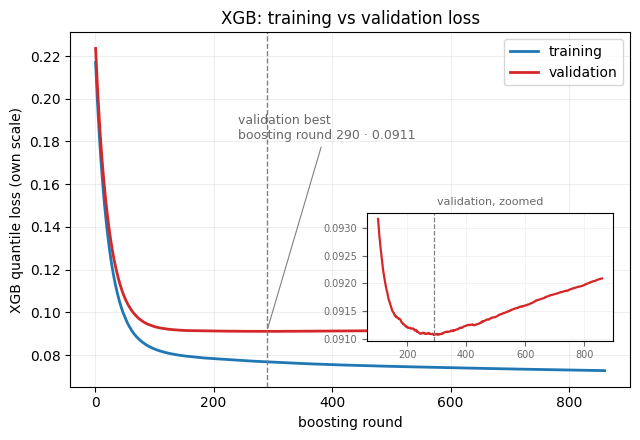

In [5]:
CURVE = True   # False = load the saved curve

# Runs past the winner's own round count on purpose, so the figure covers the region beyond it.
curve = (gbm.learning_curve(daily, "recovered", n_estimators=max(500, BEST["n_estimators"] * 2),
                            **{k: v for k, v in BEST.items() if k != "n_estimators"})
         if CURVE else pd.read_csv(config.learning_curve_csv("xgb", "recovered")))

# The TFT writes its own curve on any fit with save_checkpoint=True. Absent until notebook 02 is
# re-run on a GPU, so the figure renders with one panel or two depending on what exists.
tft_path = config.learning_curve_csv("tft", "recovered")
curves = {"xgb": curve} | ({"tft": pd.read_csv(tft_path)} if tft_path.exists() else {})

chosen = BEST["n_estimators"]
print(f"chosen n_estimators={chosen} | validation best at round "
      f"{int(curve.loc[curve.validation.idxmin(), 'round'])}")
print(f"loss at chosen={curve.loc[chosen - 1, 'validation']:.5f}  "
      f"best={curve.validation.min():.5f}  gap to train={curve.loc[chosen - 1, 'gap']:.5f}")

plots.plot_learning_curves(curves, save_path=config.PLOTS_DIR / "learning_curves.png")

### Would more regularisation do better?

The curve above shows a persistent gap between the two lines, and the intuitive reading is that the two
should meet. They should not, and cannot. Training loss is measured on the rows the model fitted, so it
is optimistically biased by construction - any model with capacity scores better in-sample than out. On
top of that the validation window is a *later* period, with its own weather, promotions and holidays, so
part of the gap is a change in the data rather than a fault in the model. A gap of zero would mean a
model with no capacity at all.

What *does* define overfitting is whether extra capacity makes validation **worse**, and the curve
answers that directly: validation improves to round 193 and degrades after, so 200 trees is the optimum.

There was still a real question the fixed-round grid could not answer. Every regulariser was searched at
`n_estimators` pinned to 200, which cannot see whether a more constrained model would have kept improving
past the point the unconstrained one turns. `tune_regularised` settles it by giving every config its own
round count via early stopping - held back from the end of **training**, never validation, so the model
never sizes itself using the window it is scored on.

Every knob measured **one at a time**, at the winning depth, each at its own best round count so none
is judged on a budget chosen for another:

| change from baseline | best round | validation min | train/val gap |
|---|---|---|---|
| **none (baseline)** | 193 | **0.09082** | 0.01426 |
| `colsample_bytree` 0.5 | 163 | 0.09099 | 0.01294 |
| `max_depth` 4 | 464 | 0.09106 | 0.01325 |
| `reg_lambda` 10 | 164 | 0.09109 | 0.01397 |
| `reg_alpha` 1 | 180 | 0.09118 | 0.01453 |
| `reg_lambda` 50 | 163 | 0.09119 | 0.01394 |
| `subsample` 0.5 | 162 | 0.09126 | 0.01376 |
| `max_depth` 3 + `subsample` 0.5 + `colsample_bytree` 0.5 | 586 | 0.09153 | **0.01117** |

Eight for eight, and in a consistent pattern: **every setting that narrows the gap costs accuracy.** The
two move in opposite directions, which is the answer - the gap is not the objective, validation loss is,
and it was already at its minimum. Nor were the constrained models starved; the slowest took three times
the winner's rounds, got them, and still lost.

Sorting by gap instead of by loss reverses the table almost exactly. That is what it looks like when a
model is at its capacity optimum rather than past it.

### One number this leaves behind

Every row above reads its best round off **validation**, and so did the grid that chose 200 trees - which
makes 200 mildly optimistic. `tune_regularised` re-picks it by early stopping on held-back **training**
days, never touching validation, and lands on **245 rounds** scoring `pinball(avg)` 0.1115 against the
validation-selected 0.1113.

**So the optimism from tuning the round count on validation is 0.0002** - small enough to ignore. The headline number is not inflated by how it was selected, and that is now measured rather than
hoped.

Re-opening any of these is one keyword argument - `tune` takes any grid - but it is hours on a CPU and off by default. The rows above are the finding; a sweep would only fill in the interior.

In [6]:
RUN_REG = False   # hours on a CPU - the probe table above is the summary

# Built here rather than kept as a module-level grid: these axes were measured and lost, so a standing
# constant would be a search the file recommends against, sitting next to the one it recommends.
REG_SWEEP = {"max_depth": [3, 4, 6], "subsample": [0.5, 0.8],
             "colsample_bytree": [0.5, 0.8], "reg_lambda": [1, 10]}

reg = gbm.tune(daily, "recovered", grid=REG_SWEEP, save=False) if RUN_REG else None
if reg is None:
    print("not run - set RUN_REG = True to search", REG_SWEEP)
reg

not run - set RUN_REG = True to search {'max_depth': [3, 4, 6], 'subsample': [0.5, 0.8], 'colsample_bytree': [0.5, 0.8], 'reg_lambda': [1, 10]}


## 3. Against the baselines and the TFT

Same scoring throughout: per date, non-stockout rows only, against recorded `sale_amount`.

These rows repeat exactly; the TFT's need a GPU to reproduce. So a gap this small is
only meaningful in one direction - it tells you the two are indistinguishable, not which is better.

In [7]:
board = pd.read_csv(config.BASELINE_SCORECARD, index_col=0)

# pinball@0.8 alongside the usual columns: it is the quantile the ordering stage reads, and the only
# one whose loss converts into money. NaN for the point-forecast baselines, which have no q80 to score.
rows = {name: {**quantile_scores(fc), "pinball@0.8": pinball_by_quantile(fc)["pinball@0.8"]}
        for name, fc in [("xgb_recovered", recovered["validation"]),
                         ("xgb_raw", raw["validation"])]}
pd.concat([pd.DataFrame(rows).T, board]).round(4)

,WAPE,WPE,MAE,pinball(avg),CRPS~,pinball@0.8,pinball@0.5,n_series,n_failed
xgb_recovered,0.3417,0.1005,0.3502,0.1116,0.2173,0.1330,NaN,NaN,NaN
xgb_raw,0.3416,-0.0218,0.3495,0.1118,0.2176,0.1362,NaN,NaN,NaN
seasonal_naive,0.4213,0.0187,0.4301,NaN,NaN,NaN,0.2212,NaN,NaN
xgboost_quantile,0.3423,-0.0187,0.3502,0.1121,0.2181,NaN,NaN,NaN,NaN
sarima,0.5210,-0.2521,0.4149,NaN,NaN,NaN,NaN,30.0,0.0


## 4. Where recovery pays

Pooled cannot settle it: scoring uses non-stockout rows, which are the rows the two targets agree on.
Split by **how often each product sells out** and the effect has somewhere to show.

Notebook 02 found the same shape here - only the chronic-stockout group improves reliably. If this
model agrees, the result is not an artefact of one architecture.

In [8]:
band = censoring_bucket(daily)

tbl = pd.concat({tag: scores_by_bucket(fc["validation"], band)
                 for tag, fc in [("raw", raw), ("recovered", recovered)]}, axis=1)
tbl[("change", "WAPE_%")] = ((tbl[("recovered", "WAPE")] / tbl[("raw", "WAPE")] - 1) * 100).round(2)
print("negative WAPE_% = recovery is MORE accurate for that group")
print(tbl.round(4).to_string())

negative WAPE_% = recovery is MORE accurate for that group
                   raw                                              recovered                                              change
              n_scored    WAPE     WPE     MAE pinball(avg)   CRPS~  n_scored    WAPE     WPE     MAE pinball(avg)   CRPS~ WAPE_%
<25% censored   3955.0  0.4681  0.0195  0.3384       0.1080  0.2962    3955.0  0.4613  0.1175  0.3335       0.1080  0.2962  -1.45
25-50%         30345.0  0.3584  0.0044  0.2938       0.0941  0.2284   30345.0  0.3686  0.1118  0.3025       0.0964  0.2341   2.85
50-75%         12319.0  0.3085 -0.0169  0.4275       0.1355  0.1942   12319.0  0.3123  0.1107  0.4346       0.1380  0.1977   1.23
>=75%           1375.0  0.2911 -0.2049  0.9061       0.3011  0.1956    1375.0  0.2244  0.0014  0.6946       0.2217  0.1440 -22.91
ALL            47994.0  0.3416 -0.0218  0.3495       0.1118  0.2176   47994.0  0.3417  0.1005  0.3502       0.1116  0.2173   0.03


## 5. Lost sales against waste

WAPE charges a unit too many and a unit too few identically. A shop does not: a bin costs one item, an
empty shelf costs a sale. This splits the error by direction, ordering at `q50` on days recorded sales
are the true demand.

`worth_it_above_ratio` is the column that decides it - how much worse an empty shelf must be than a bin
for recovery to pay. Below 1.0 means it pays even if the two cost the same.

In [9]:
# One implementation, in src/utils/metrics.py - notebook 03 renders the same table for the tree,
# and a second copy here is how the two silently drift apart.
trade = lost_sales_vs_waste({"raw": raw["validation"], "recovered": recovered["validation"]}, band)
print(trade.to_string())
print()
print("worth_it_above_ratio = how much worse an empty shelf must be than a bin for recovery to pay.")
print("Below 1.0 means it pays even if waste and a lost sale cost exactly the same.")

               lost_sales_%_raw  waste_%_raw  lost_sales_%_recovered  waste_%_recovered  lost_sales_recovered_pts  waste_added_pts  worth_it_above_ratio
band                                                                                                                                                    
<25% censored              22.7         24.0                    17.4               28.6                       5.3              4.6                  0.87
25-50%                     17.6         18.2                    12.8               24.1                       4.8              5.9                  1.23
50-75%                     16.1         14.6                    10.0               21.2                       6.1              6.6                  1.08
>=75%                      25.0          4.2                    11.3               11.1                      13.7              6.9                  0.50

worth_it_above_ratio = how much worse an empty shelf must be than a bin for recov